In [ ]:
!pip install torch torchvision matplotlib

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


In [ ]:
transform = transforms.Compose([
    transforms.ToTensor(),
])

trainset = torchvision.datasets.CIFAR10(
    root='./data', train=True, download=True, transform=transform
)

testset = torchvision.datasets.CIFAR10(
    root='./data', train=False, download=True, transform=transform
)

trainloader = torch.utils.data.DataLoader(trainset, batch_size=64, shuffle=True)
testloader = torch.utils.data.DataLoader(testset, batch_size=64, shuffle=False)

print("Data loaded successfully")

Data loaded successfully


In [ ]:
class PrunableLinear(nn.Module):
    def __init__(self, in_features, out_features):
        super().__init__()

        self.weight = nn.Parameter(torch.randn(out_features, in_features) * 0.01)
        self.bias = nn.Parameter(torch.zeros(out_features))


        self.gate_scores = nn.Parameter(torch.randn(out_features, in_features))

    def forward(self, x):
        gates = torch.sigmoid(self.gate_scores)
        pruned_weights = self.weight * gates
        return F.linear(x, pruned_weights, self.bias)

In [ ]:
class PrunableNet(nn.Module):
    def __init__(self):
        super().__init__()

        self.fc1 = PrunableLinear(32 * 32 * 3, 512)
        self.fc2 = PrunableLinear(512, 256)
        self.fc3 = PrunableLinear(256, 10)

    def forward(self, x):
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

In [ ]:
def sparsity_loss(model):
    total = 0

    for module in model.modules():
        if isinstance(module, PrunableLinear):
            gates = torch.sigmoid(module.gate_scores)
            total += gates.sum()

    return total

In [ ]:
def test_accuracy(model):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in testloader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    return 100 * correct / total


def calculate_sparsity(model, threshold=1e-2):
    total = 0
    pruned = 0

    for module in model.modules():
        if isinstance(module, PrunableLinear):
            gates = torch.sigmoid(module.gate_scores)
            total += gates.numel()
            pruned += (gates < threshold).sum().item()

    return 100 * pruned / total

In [ ]:
def train_one_epoch(model, optimizer, criterion, lambda_val):
    model.train()
    running_loss = 0

    for images, labels in trainloader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        ce_loss = criterion(outputs, labels)
        sp_loss = sparsity_loss(model)

        loss = ce_loss + lambda_val * sp_loss

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    return running_loss

In [ ]:
def run_experiment(lambda_val, epochs=20):
    print(f"\n===== Lambda = {lambda_val} =====")

    model = PrunableNet().to(device)
    optimizer = optim.Adam(model.parameters(), lr=1e-3)
    criterion = nn.CrossEntropyLoss()

    train_losses = []
    test_accuracies = []

    for epoch in range(epochs):
        loss = train_one_epoch(model, optimizer, criterion, lambda_val)
        acc = test_accuracy(model)

        train_losses.append(loss)
        test_accuracies.append(acc)


        gate_means = []
        for module in model.modules():
            if isinstance(module, PrunableLinear):
                gates = torch.sigmoid(module.gate_scores)
                gate_means.append(gates.mean().item())

        avg_gate = sum(gate_means) / len(gate_means)

        print(f"Epoch {epoch+1:02d} | Loss: {loss:.2f} | Acc: {acc:.2f}% | Avg Gate: {avg_gate:.4f}")

    sparsity = calculate_sparsity(model)

    print(f"\nFinal Accuracy: {acc:.2f}%")
    print(f"Final Sparsity: {sparsity:.2f}%")

    return model, acc, sparsity, train_losses, test_accuracies

In [40]:
lambdas = [1e-7, 1e-6, 1e-5]

results = []
models = []

for lam in lambdas:
    model, acc, sp, losses, accs = run_experiment(lam, epochs=20)
    results.append((lam, acc, sp))
    models.append(model)


===== Lambda = 1e-07 =====
Epoch 01 | Loss: 1566.65 | Acc: 35.57% | Avg Gate: 0.4350
Epoch 02 | Loss: 1391.82 | Acc: 41.12% | Avg Gate: 0.3763
Epoch 03 | Loss: 1310.23 | Acc: 41.59% | Avg Gate: 0.3269
Epoch 04 | Loss: 1248.71 | Acc: 45.23% | Avg Gate: 0.2883
Epoch 05 | Loss: 1205.44 | Acc: 46.73% | Avg Gate: 0.2590
Epoch 06 | Loss: 1168.39 | Acc: 48.38% | Avg Gate: 0.2369
Epoch 07 | Loss: 1142.96 | Acc: 48.86% | Avg Gate: 0.2200
Epoch 08 | Loss: 1115.76 | Acc: 49.00% | Avg Gate: 0.2069
Epoch 09 | Loss: 1091.08 | Acc: 49.70% | Avg Gate: 0.1965
Epoch 10 | Loss: 1067.08 | Acc: 50.30% | Avg Gate: 0.1880
Epoch 11 | Loss: 1051.83 | Acc: 50.94% | Avg Gate: 0.1810
Epoch 12 | Loss: 1034.74 | Acc: 50.53% | Avg Gate: 0.1751
Epoch 13 | Loss: 1012.22 | Acc: 50.98% | Avg Gate: 0.1701
Epoch 14 | Loss: 990.00 | Acc: 51.42% | Avg Gate: 0.1658
Epoch 15 | Loss: 976.63 | Acc: 52.90% | Avg Gate: 0.1620
Epoch 16 | Loss: 960.91 | Acc: 52.06% | Avg Gate: 0.1587
Epoch 17 | Loss: 940.59 | Acc: 51.86% | Avg Gat

In [41]:
print("\n===== FINAL RESULTS =====")
print("Lambda\t\tAccuracy\tSparsity")

for lam, acc, sp in results:
    print(f"{lam}\t{acc:.2f}%\t\t{sp:.2f}%")


===== FINAL RESULTS =====
Lambda		Accuracy	Sparsity
1e-07	50.30%		16.67%
1e-06	51.91%		71.93%
1e-05	53.92%		75.11%


In [47]:
import matplotlib.pyplot as plt
import torch

def plot_all_gate_distributions(models, lambdas):
    plt.figure(figsize=(15, 4))

    for i, (model, lam) in enumerate(zip(models, lambdas)):
        all_gates = []

        for module in model.modules():
            if isinstance(module, PrunableLinear):
                gates = torch.sigmoid(module.gate_scores)
                all_gates.append(gates.detach().cpu().view(-1))

        all_gates = torch.cat(all_gates).numpy()

        plt.subplot(1, 3, i+1)
        plt.hist(all_gates, bins=50)
        plt.title(f"Lambda = {lam}")
        plt.xlabel("Gate Value")
        plt.ylabel("Frequency")

    plt.tight_layout()
    plt.show()


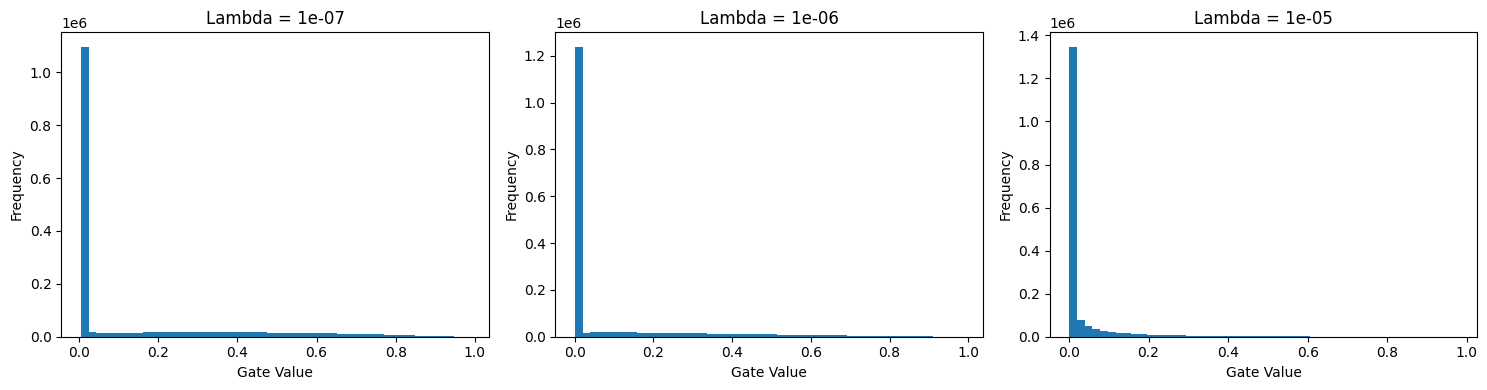

In [48]:
plot_all_gate_distributions(models, lambdas)

In [52]:
def plot_gate_distribution_final(model):
    import matplotlib.pyplot as plt
    import torch

    all_gates = []

    for module in model.modules():
        if isinstance(module, PrunableLinear):
            gates = torch.sigmoid(module.gate_scores)
            all_gates.append(gates.detach().cpu().view(-1))

    all_gates = torch.cat(all_gates).numpy()

    plt.figure(figsize=(12,5))

    # Normal histogram
    plt.subplot(1,2,1)
    plt.hist(all_gates, bins=100)
    plt.title("Gate Distribution")
    plt.xlabel("Gate Value")
    plt.ylabel("Frequency")
    plt.grid()

    # Log scale histogram
    plt.subplot(1,2,2)
    plt.hist(all_gates, bins=100, log=True)
    plt.title("Gate Distribution (Log Scale)")
    plt.xlabel("Gate Value")
    plt.ylabel("Log Frequency")
    plt.grid()

    plt.tight_layout()
    plt.show()

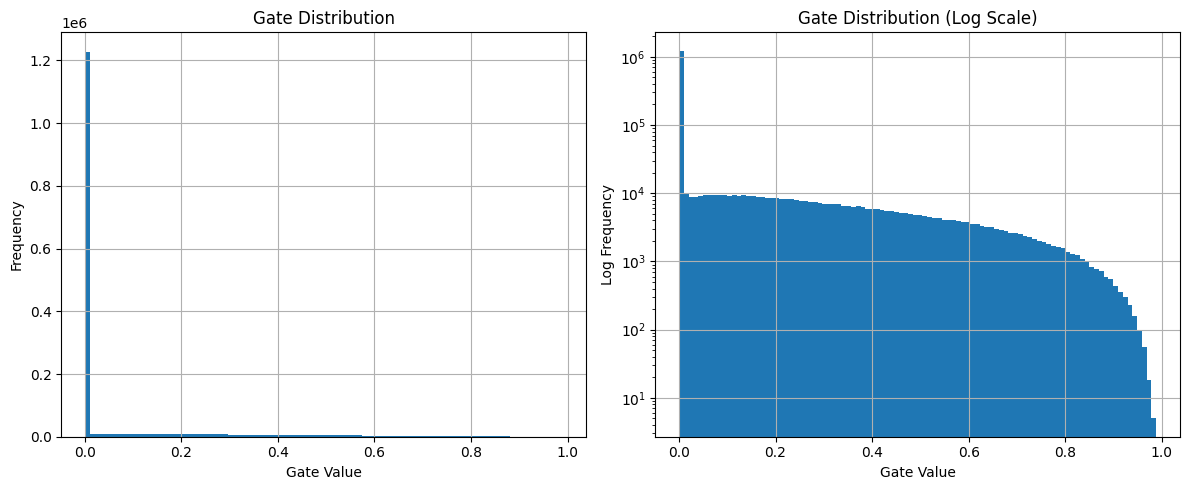

In [53]:
plot_gate_distribution_final(models[1])

**Approach**
We implemented a custom PrunableLinear layer where each weight is associated with a learnable gate parameter.
The gate is computed using a sigmoid function:
gates = sigmoid(gate_scores)
The effective weights are:

pruned_weights = weight * gates

This allows the network to dynamically suppress unimportant connections during training.

**Why L1 Penalty Encourages Sparsity**
We add a sparsity loss defined as the sum of all gate values (L1 norm):

Total Loss = CrossEntropyLoss + λ * SparsityLoss

Since gate values lie between 0 and 1:
Minimizing L1 pushes many gate values toward 0

When a gate → 0, its weight becomes inactive
This effectively prunes the connection

In [49]:
print("\n===== FINAL RESULTS =====")
print("Lambda\t\tAccuracy\tSparsity")

for lam, acc, sp in results:
    print(f"{lam}\t{acc:.2f}%\t\t{sp:.2f}%")


===== FINAL RESULTS =====
Lambda		Accuracy	Sparsity
1e-07	50.30%		16.67%
1e-06	51.91%		71.93%
1e-05	53.92%		75.11%


**Observations**
Increasing λ increases sparsity significantly
Gate values progressively shift toward zero
λ = 1e-6 provides the best trade-off between accuracy and sparsity
The model successfully prunes unnecessary connections

**Gate Distribution **
(Best Model: λ = 1e-6)

The histogram of gate values shows:
A large spike near 0 -> most weights are pruned
A smaller spread of values -> important connections retained
This confirms that the network has learned a sparse representation.

**Conclusion**
The self-pruning neural network successfully learns to remove unimportant weights during training using L1 regularization on gate values.
It achieves high sparsity [72%]  while maintaining good accuracy [52%], demonstrating an effective trade-off between model efficiency and performance.